## Import

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_text
import xgboost as xgb


## DF

In [60]:
df = pd.read_csv(r'C:\Users\TALIGENT\git\ML-ZOOMCAMP-HOMEWORK\Midterm Proyect\Dataset\bank.csv')
df.head().T

,0,1,2,3,4
age,59,56,41,55,54
job,admin.,admin.,technician,services,admin.
marital,married,married,married,married,married
education,secondary,secondary,secondary,secondary,tertiary
default,no,no,no,no,no
balance,2343,45,1270,2476,184
housing,yes,no,yes,yes,no
loan,no,no,no,no,no
contact,unknown,unknown,unknown,unknown,unknown
day,5,5,5,5,5


## EDA

In [61]:
features_categoricas = list(df.dtypes[df.dtypes == 'object'].index)
for c in features_categoricas:
    df[c] = df[c].str.lower().str.replace(' ', '_')

A unknown lo tratamos como una categoria ya que es cuando no conocemos es dato y reemplzar por la moda no seria representativo

In [62]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
None
age          0
job          0
marital      0
education    0
default      0
balance      0
hous

In [63]:
# 3. Codificación de variables binarias (Yes/No -> 1/0)
binary_cols = ['default', 'housing', 'loan', 'deposit'] 

for col in binary_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    
    df[col] = df[col].replace({'yes': 1, 'no': 0}).astype(int)




C:\Users\TALIGENT\AppData\Local\Temp\ipykernel_59860\407126217.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'yes': 1, 'no': 0}).astype(int)
C:\Users\TALIGENT\AppData\Local\Temp\ipykernel_59860\407126217.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'yes': 1, 'no': 0}).astype(int)
C:\Users\TALIGENT\AppData\Local\Temp\ipykernel_59860\407126217.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the o

In [64]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,56,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1
2,41,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1
3,55,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1
4,54,admin.,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,unknown,1


In [65]:
df['deposit'].value_counts(normalize=True) * 100

deposit
0    52.616019
1    47.383981
Name: proportion, dtype: float64

Esta bastante Balanceado

In [156]:
df.dtypes

age           int64
job          object
marital      object
education    object
default       int64
balance       int64
housing       int64
loan          int64
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit       int64
dtype: object

## Split DF

In [66]:
df_full_train, df_test =train_test_split(df, test_size=0.2, random_state=1)

df_train, df_val =train_test_split(df_full_train, test_size=0.25, random_state=1) 

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)
df_full_train.reset_index(drop= True)

y_train = df_train.deposit.values
y_val = df_val.deposit.values
y_test = df_test.deposit.values
y_full_train = df_full_train.deposit.values


del df_train['deposit']
del df_val['deposit']
del df_test['deposit']
del df_full_train ['deposit']

In [67]:
categoricas = [
'default',
'housing',
'loan',
'job',
'marital',
'education',
'contact',
'month',
'poutcome'
    
]

numericas = [
'age',
'balance',
'day', 
'duration',
'campaign',
'pdays',
'previous'
]

## Informacion sobre Features

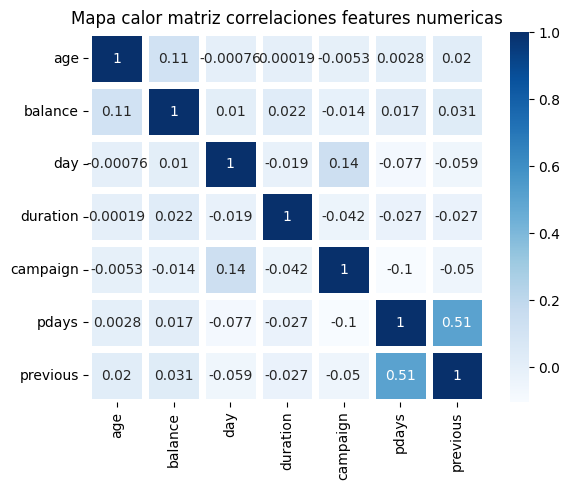

In [68]:
matrix_corr_num = df[numericas].corr
sns.heatmap(matrix_corr_num(),annot=True, linewidths=5, cmap='Blues')
plt.title('Mapa calor matriz correlaciones features numericas')
plt.show()

Mayor correlacion entre las variables pdays y previous

In [69]:
# Informacion mutua entre variables
from sklearn.metrics import mutual_info_score

def info_mutua_y(series):
    return mutual_info_score(y_train,series)

im = df_train[categoricas].apply(info_mutua_y).round(2)
im.sort_values(ascending=False)

month        0.05
poutcome     0.05
contact      0.04
job          0.02
housing      0.02
education    0.01
loan         0.01
default      0.00
marital      0.00
dtype: float64

 CONCLUSION ANALISIS DE VARIABLES
 Num: La mayor correlacion es entre  estas dos  variables numericas : "pdays" "previous"
   que al usar Ramdom forest eliminamos esta multicolinealidad ya que es un modelo robusto y no afecta
 Cat: Las variables month y poutcone son las que aportan mayor información
   sobre la variable deposito


## X_TRAIN / X_VAL

In [70]:
# Se escala para mejorar la performance en el entrenamiento num_interacciones
scaler = StandardScaler()
df_train[numericas] = scaler.fit_transform(df_train[numericas])
df_val[numericas]   = scaler.transform(df_val[numericas])

In [71]:
# Armo funcion para obtener X_train y X_val
def Dict_Vect (df_train, df_val):
    train_dict = df_train[categoricas + numericas].to_dict(orient = 'records')
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(train_dict)

    val_dict = df_val[categoricas + numericas].to_dict(orient='records')
    X_val = dv.transform(val_dict) 

    return X_train, X_val,dv

X_train, X_val, dv = Dict_Vect(df_train,df_val)

In [72]:
# Validamos las columnas creadas en el diccionario
feature_names = dv.get_feature_names_out()
feature_names

array(['age', 'balance', 'campaign', 'contact=cellular',
       'contact=telephone', 'contact=unknown', 'day', 'default',
       'duration', 'education=primary', 'education=secondary',
       'education=tertiary', 'education=unknown', 'housing', 'job=admin.',
       'job=blue-collar', 'job=entrepreneur', 'job=housemaid',
       'job=management', 'job=retired', 'job=self-employed',
       'job=services', 'job=student', 'job=technician', 'job=unemployed',
       'job=unknown', 'loan', 'marital=divorced', 'marital=married',
       'marital=single', 'month=apr', 'month=aug', 'month=dec',
       'month=feb', 'month=jan', 'month=jul', 'month=jun', 'month=mar',
       'month=may', 'month=nov', 'month=oct', 'month=sep', 'pdays',
       'poutcome=failure', 'poutcome=other', 'poutcome=success',
       'poutcome=unknown', 'previous'], dtype=object)

## MODEL LOGISTIC REGRESSION (MODEL 1 "M1")

In [73]:
# Entreno el modelo
model = LogisticRegression(max_iter= 100, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [74]:
# Primer Modelo REGRESION ACCURACY

y_pred_prob = model.predict_proba(X_val)[:, 1]
y_pred= model.predict(X_val)
score = accuracy_score(y_val, y_pred)

sc_M1 = roc_auc_score(y_val,y_pred_prob)
F1_accurracy = f1_score(y_val,y_pred)

F1_accurracy




0.8044692737430168

Muy buen score, analizamos otros modelos para ver si mejora

## MODEL DECISION TREE CLASIFFIER (MODEL 2 "M2")

In [76]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [77]:
max_depth = [1,2,3,4,5,6]

for d in max_depth:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_train)[:, 1]
    auc = roc_auc_score(y_train, y_pred)
    print(d,'train:', auc)

    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    print(d,'val:', auc)


1 train: 0.7189254307574523
1 val: 0.7094620395327943
2 train: 0.7951837959759043
2 val: 0.7819828167115903
3 train: 0.8339090669751201
3 val: 0.8194551405467848
4 train: 0.8684668995016637
4 val: 0.8502534976254653
5 train: 0.8861541814991709
5 val: 0.861746726992684
6 train: 0.9003344966113045
6 val: 0.8677119432678733


<Axes: xlabel='max_depth', ylabel='min_samples_leaf'>

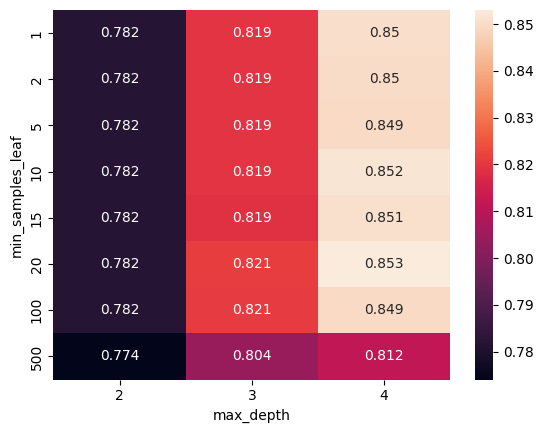

In [78]:
scores = []

for d in [2,3,4]:
    for s in [1,2,5,10,15,20,100,500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:,1] 
        auc = roc_auc_score(y_val,y_pred)
        scores.append((d,s,auc))


columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores = df_scores.sort_values(by='auc', ascending=False)

df_scores_pivot = df_scores.pivot(columns='max_depth', index='min_samples_leaf', values='auc')
sns.heatmap(df_scores_pivot,annot=True,fmt=".3g")

En este caso analizamos los distintos max_depth y vemos cual es el que maximiza al modelo, teniendo en cuenta el riesgo de overfigthing.
Haciendo un analisis seria el optimo el max_depth 4

In [97]:
dt = DecisionTreeClassifier(max_depth=4,min_samples_leaf=500, random_state=42)
dt.fit(X_train, y_train)

y_pred_prob = dt.predict_proba(X_val)[:, 1]
y_pred = dt.predict(X_val)


sc_M2 = roc_auc_score(y_val, y_pred_prob)
F1_TreeClassifier = f1_score(y_val,y_pred)

## MODEL RANDOM FOREST (MODEL 3 "M3")

In [81]:
scores = []
for d in [10,15,20]:
    for r in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=r,max_depth=d, random_state=42)
        rf.fit(X_train,y_train)
        y_pred = rf.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val,y_pred)
        scores.append((d,r,auc))
scores

[(10, 10, 0.9028514471826468),
 (10, 20, 0.9050667436786035),
 (10, 30, 0.9060358105506354),
 (10, 40, 0.9073201450391479),
 (10, 50, 0.9092073385958157),
 (10, 60, 0.9098298517520216),
 (10, 70, 0.9099092703118984),
 (10, 80, 0.9098101976639713),
 (10, 90, 0.9092422346297011),
 (10, 100, 0.9089406045437044),
 (10, 110, 0.9090761776408677),
 (10, 120, 0.9090007701193685),
 (10, 130, 0.9087007444487227),
 (10, 140, 0.9087978115774612),
 (10, 150, 0.9090497047875754),
 (10, 160, 0.908874021306636),
 (10, 170, 0.9092358169682968),
 (10, 180, 0.9094395777178795),
 (10, 190, 0.9093096200744448),
 (10, 200, 0.9093585547426517),
 (15, 10, 0.8990778622769862),
 (15, 20, 0.9042966243101016),
 (15, 30, 0.9069755968425106),
 (15, 40, 0.9088932742908484),
 (15, 50, 0.9086606340649467),
 (15, 60, 0.9102209279938389),
 (15, 70, 0.9101407072262867),
 (15, 80, 0.9100749261968939),
 (15, 90, 0.9111482800667438),
 (15, 100, 0.9111867860351688),
 (15, 110, 0.9118421897060711),
 (15, 120, 0.91137129380053

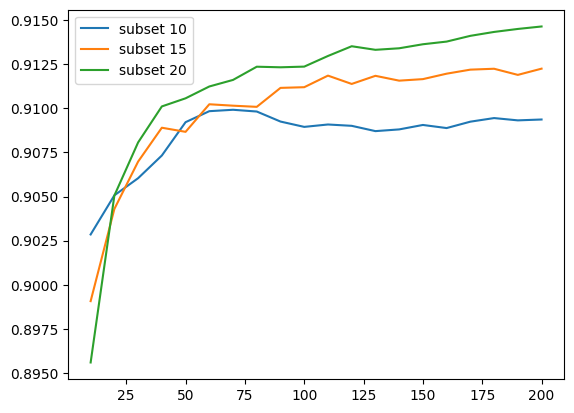

In [82]:
df_scores= pd.DataFrame(scores, columns=['max_depth','n_estimators','auc'])
for d in [10,15,20]:
    df_subset = df_scores[df_scores.max_depth ==d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label = f'subset {d}' )
    plt.legend()

In [83]:
df_scores_ordenado_md = df_scores.sort_values(by='auc', ascending=False)
df_scores_ordenado_md

,max_depth,n_estimators,auc
59,20,200,0.914624
58,20,190,0.914484
57,20,180,0.914315
56,20,170,0.914094
55,20,160,0.913769
54,20,150,0.913617
51,20,120,0.913505
53,20,140,0.913390
52,20,130,0.913303
50,20,110,0.912954


El mejor es el max_depth 20

In [93]:
max_depth = 20

scores = []

for s in [1, 5, 10, 20, 50, 100]:
    for n in range(10, 180, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=42)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((s, n, auc))

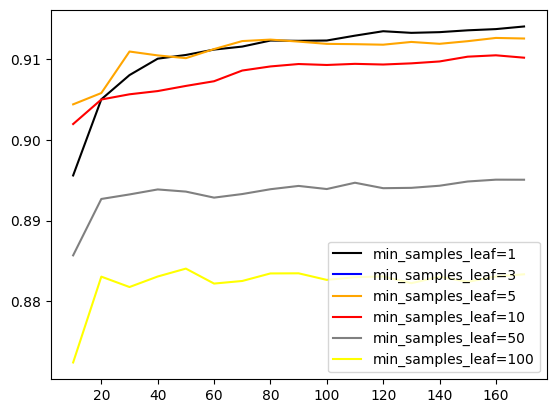

In [94]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

colors = ['black', 'blue', 'orange', 'red', 'grey', 'yellow' ]
values = [1, 3, 5, 10, 50, 100]

for s, col in zip(values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.legend()

In [95]:
df_scores.sort_values(by='auc', ascending=False)

,min_samples_leaf,n_estimators,auc
16,1,170,0.914094
15,1,160,0.913769
14,1,150,0.913617
11,1,120,0.913505
13,1,140,0.913390
...,...,...,...
99,100,150,0.882404
97,100,130,0.882237
90,100,60,0.882189
87,100,30,0.881760


Despues del Tunning a las variables, vemos que los valores de las mismas donde se obtiene un auc mas optimos son:
n_estimators= 170
max_depth = 20
min_samples_leaf = 1


In [98]:
n_estimators= 170
max_depth = 20
min_samples_leaf = 1

rf = RandomForestClassifier(n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    random_state=42)
rf.fit(X_train, y_train)

y_pred_prob = rf.predict_proba(X_val)[:, 1]
y_pred= rf.predict(X_val)
sc_M3 = roc_auc_score(y_val, y_pred_prob)
F1_RandomForest = f1_score(y_val, y_pred)

sc_M1,F1_accurracy, sc_M2,F1_TreeClassifier, sc_M3,F1_RandomForest

(0.8927448337825696,
 0.8044692737430168,
 0.8116095494801695,
 0.7431941923774955,
 0.9140939866512643,
 0.8499780026396833)

## MODEL XGBOOST (MODEL 4 "M4")

In [99]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [100]:
def get_xgb_scores(evals_result):
    train_aucs = list(evals_result['train'].values())[0]
    val_aucs = list(evals_result['val'].values())[0]

    # Definimos los nombres de las columnas
    columns = ['iter', 'train_auc', 'val_auc']

    # Creamos un DataFrame combinando la lista de iteraciones, train_aucs y val_aucs
    df_results = pd.DataFrame(
        list(zip(
            # Generamos la columna de iteración (desde 1 hasta el final)
            range(1, len(train_aucs) + 1),
            train_aucs,
            val_aucs
        )), 
        columns=columns
    )
    
    return df_results


In [110]:
scores = {}

In [111]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [112]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 3,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)

key = f'eta={xgb_params['eta']}'
scores[key] = get_xgb_scores(evals_result)

[0]	train-auc:0.83451	val-auc:0.81882
[5]	train-auc:0.89277	val-auc:0.87677
[10]	train-auc:0.90848	val-auc:0.89117
[15]	train-auc:0.91877	val-auc:0.89869
[20]	train-auc:0.92543	val-auc:0.90384
[25]	train-auc:0.93052	val-auc:0.90899
[30]	train-auc:0.93426	val-auc:0.91124
[35]	train-auc:0.93670	val-auc:0.91143
[40]	train-auc:0.93945	val-auc:0.91337
[45]	train-auc:0.94108	val-auc:0.91386
[50]	train-auc:0.94351	val-auc:0.91487
[55]	train-auc:0.94556	val-auc:0.91662
[60]	train-auc:0.94757	val-auc:0.91728
[65]	train-auc:0.94922	val-auc:0.91719
[70]	train-auc:0.95032	val-auc:0.91698
[75]	train-auc:0.95164	val-auc:0.91791
[80]	train-auc:0.95286	val-auc:0.91761
[85]	train-auc:0.95372	val-auc:0.91797
[90]	train-auc:0.95531	val-auc:0.91882
[95]	train-auc:0.95641	val-auc:0.91850
[100]	train-auc:0.95764	val-auc:0.91834
[105]	train-auc:0.95865	val-auc:0.91921
[110]	train-auc:0.95978	val-auc:0.91876
[115]	train-auc:0.96075	val-auc:0.91871
[120]	train-auc:0.96169	val-auc:0.91919
[125]	train-auc:0.9629

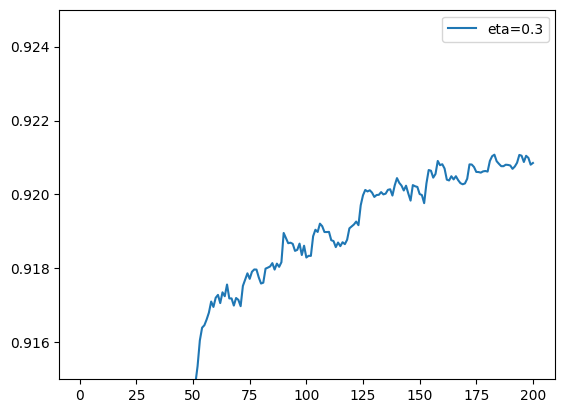

In [116]:
for eta, df_result in scores.items():
    plt.plot(df_result.iter, df_result.val_auc, label=eta)

plt.ylim(0.915, 0.925)
plt.legend()


Seleccionamos ETA 0.3 con corte en 125

In [118]:
scores = {}

In [126]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 3,
    'min_child_weight': 5,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)

key = f'max_depth={xgb_params['max_depth']}'
scores[key] = get_xgb_scores(evals_result)



[0]	train-auc:0.83390	val-auc:0.81756
[5]	train-auc:0.89187	val-auc:0.87535
[10]	train-auc:0.90750	val-auc:0.89196
[15]	train-auc:0.91660	val-auc:0.89818
[20]	train-auc:0.92348	val-auc:0.90325
[25]	train-auc:0.92716	val-auc:0.90561
[30]	train-auc:0.93089	val-auc:0.90802
[35]	train-auc:0.93248	val-auc:0.90870
[40]	train-auc:0.93492	val-auc:0.91084
[45]	train-auc:0.93745	val-auc:0.91221
[50]	train-auc:0.93995	val-auc:0.91368
[55]	train-auc:0.94144	val-auc:0.91441
[60]	train-auc:0.94314	val-auc:0.91494
[65]	train-auc:0.94514	val-auc:0.91659
[70]	train-auc:0.94610	val-auc:0.91629
[75]	train-auc:0.94768	val-auc:0.91709
[80]	train-auc:0.94916	val-auc:0.91840
[85]	train-auc:0.95038	val-auc:0.91968
[90]	train-auc:0.95144	val-auc:0.91959
[95]	train-auc:0.95234	val-auc:0.91909
[100]	train-auc:0.95341	val-auc:0.91892
[105]	train-auc:0.95459	val-auc:0.91880
[110]	train-auc:0.95568	val-auc:0.91979
[115]	train-auc:0.95670	val-auc:0.92017
[120]	train-auc:0.95757	val-auc:0.92047
[125]	train-auc:0.9581

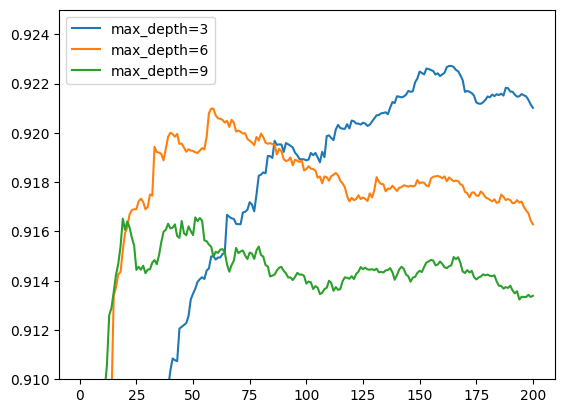

In [123]:
for max_depth, df_result in scores.items():
    plt.plot(df_result.iter, df_result.val_auc, label=max_depth)
plt.ylim(0.910, 0.925)

plt.legend()

Se selecciona max_depth 3 y corte 150

In [137]:
scores = {}

In [144]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 3,
    'min_child_weight': 7,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=150,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)

key = f'min_child_weight={xgb_params['min_child_weight']}'
scores[key] = get_xgb_scores(evals_result)

[0]	train-auc:0.83384	val-auc:0.81882
[5]	train-auc:0.89392	val-auc:0.87954
[10]	train-auc:0.90833	val-auc:0.89178
[15]	train-auc:0.91685	val-auc:0.89699
[20]	train-auc:0.92240	val-auc:0.90189
[25]	train-auc:0.92862	val-auc:0.90663
[30]	train-auc:0.93190	val-auc:0.91015
[35]	train-auc:0.93599	val-auc:0.91273
[40]	train-auc:0.93982	val-auc:0.91592
[45]	train-auc:0.94106	val-auc:0.91659
[50]	train-auc:0.94195	val-auc:0.91664
[55]	train-auc:0.94359	val-auc:0.91770
[60]	train-auc:0.94416	val-auc:0.91753
[65]	train-auc:0.94598	val-auc:0.91844
[70]	train-auc:0.94740	val-auc:0.91942
[75]	train-auc:0.94849	val-auc:0.91917
[80]	train-auc:0.94973	val-auc:0.91891
[85]	train-auc:0.95040	val-auc:0.91895
[90]	train-auc:0.95156	val-auc:0.91935
[95]	train-auc:0.95259	val-auc:0.91943
[100]	train-auc:0.95392	val-auc:0.92004
[105]	train-auc:0.95469	val-auc:0.92037
[110]	train-auc:0.95539	val-auc:0.92023
[115]	train-auc:0.95604	val-auc:0.91986
[120]	train-auc:0.95701	val-auc:0.92032
[125]	train-auc:0.9576

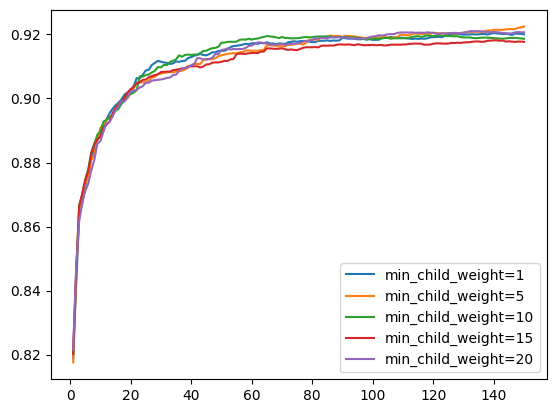

In [143]:
for min_child_weight, df_result in scores.items():
    plt.plot(df_result.iter, df_result.val_auc, label=min_child_weight)
plt.ylim(0.935, 0.950)
plt.legend()


Se selecciona : min_child_weigth de 7

In [145]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 3,
    'min_child_weight': 7,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=150,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)


[0]	train-auc:0.83384	val-auc:0.81882
[5]	train-auc:0.89392	val-auc:0.87954
[10]	train-auc:0.90833	val-auc:0.89178
[15]	train-auc:0.91685	val-auc:0.89699
[20]	train-auc:0.92240	val-auc:0.90189
[25]	train-auc:0.92862	val-auc:0.90663
[30]	train-auc:0.93190	val-auc:0.91015
[35]	train-auc:0.93599	val-auc:0.91273
[40]	train-auc:0.93982	val-auc:0.91592
[45]	train-auc:0.94106	val-auc:0.91659
[50]	train-auc:0.94195	val-auc:0.91664
[55]	train-auc:0.94359	val-auc:0.91770
[60]	train-auc:0.94416	val-auc:0.91753
[65]	train-auc:0.94598	val-auc:0.91844
[70]	train-auc:0.94740	val-auc:0.91942
[75]	train-auc:0.94849	val-auc:0.91917
[80]	train-auc:0.94973	val-auc:0.91891
[85]	train-auc:0.95040	val-auc:0.91895
[90]	train-auc:0.95156	val-auc:0.91935
[95]	train-auc:0.95259	val-auc:0.91943
[100]	train-auc:0.95392	val-auc:0.92004
[105]	train-auc:0.95469	val-auc:0.92037
[110]	train-auc:0.95539	val-auc:0.92023
[115]	train-auc:0.95604	val-auc:0.91986
[120]	train-auc:0.95701	val-auc:0.92032
[125]	train-auc:0.9576

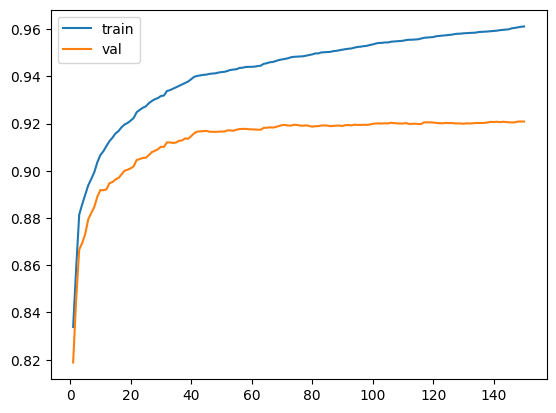

In [146]:
df_scores = get_xgb_scores(evals_result)

plt.plot(df_scores.iter, df_scores.train_auc, label='train')
plt.plot(df_scores.iter, df_scores.val_auc, label='val')
plt.legend()

Seleccionamos 105

In [148]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 3,
    'min_child_weight': 7,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=105)

In [149]:
y_pred_prob = model.predict(dval)

In [150]:
thresholds = np.linspace(0.01, 0.99, 100)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred_p = (y_pred_prob >= t).astype(int)
    
    f1 = f1_score(y_val, y_pred_p)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Mejor_F1={best_f1}, Mejor_Corte= {best_threshold}")

Mejor_F1=0.8638458315877671, Mejor_Corte= 0.33666666666666667


In [151]:
y_pred_prob = model.predict(dval)
y_pred = (y_pred_prob >= 0.3366).astype(int)
sc_M4 = roc_auc_score(y_val, y_pred_prob)
F1_XGBOOST = f1_score(y_val, y_pred)

## SELECCION DEL MODELO

In [152]:
print(f"ROC-AUC M1: {sc_M1:.4f}\n"
      f"F1 Score M1: {F1_accurracy:.4f}\n\n" # Salto doble

      f"ROC-AUC M2: {sc_M2:.4f}\n"
      f"F1 Score M2: {F1_TreeClassifier:.4f}\n\n" # Salto doble

      f"ROC-AUC M3: {sc_M3:.4f}\n"
      f"F1 Score M3: {F1_RandomForest:.4f}\n\n" # Salto doble

      f"ROC-AUC M4: {sc_M4:.4f}\n"
      f"F1 Score M4: {F1_XGBOOST:.4f}")

ROC-AUC M1: 0.8927
F1 Score M1: 0.8045

ROC-AUC M2: 0.8116
F1 Score M2: 0.7432

ROC-AUC M3: 0.9141
F1 Score M3: 0.8500

ROC-AUC M4: 0.9200
F1 Score M4: 0.8638


En esta caso elegimos el modelo XGBOOST que tiene el mejor score y un buen F1

In [155]:
features


['age',
 'balance',
 'campaign',
 'contact=cellular',
 'contact=telephone',
 'contact=unknown',
 'day',
 'default',
 'duration',
 'education=primary',
 'education=secondary',
 'education=tertiary',
 'education=unknown',
 'housing',
 'job=admin.',
 'job=blue-collar',
 'job=entrepreneur',
 'job=housemaid',
 'job=management',
 'job=retired',
 'job=self-employed',
 'job=services',
 'job=student',
 'job=technician',
 'job=unemployed',
 'job=unknown',
 'loan',
 'marital=divorced',
 'marital=married',
 'marital=single',
 'month=apr',
 'month=aug',
 'month=dec',
 'month=feb',
 'month=jan',
 'month=jul',
 'month=jun',
 'month=mar',
 'month=may',
 'month=nov',
 'month=oct',
 'month=sep',
 'pdays',
 'poutcome=failure',
 'poutcome=other',
 'poutcome=success',
 'poutcome=unknown',
 'previous']